<a href="https://colab.research.google.com/github/Anish233179/trader-sentiment-analysis/blob/main/fear_greed_index.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12,6)
sns.set_style("whitegrid")

In [4]:
sentiment = pd.read_csv("/content/drive/MyDrive/fear_greed_index.csv")
trades = pd.read_csv("/content/drive/MyDrive/historical_data.csv")

In [5]:
sentiment

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [6]:
trades

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102569,0x8477e447846c758f5a675856001ea72298fd9cb5,ZRO,4.8150,103.80,499.80,SELL,20-07-2024 21:15,-3299.600000,Open Short,0.0,0xb4f513c5fe0067b3f6f9040dcf76e301880043297980...,30526240127,False,0.049979,5.610000e+13,1.720000e+12
102570,0x8477e447846c758f5a675856001ea72298fd9cb5,ZRO,4.8200,103.70,499.83,SELL,20-07-2024 21:16,-3403.400000,Open Short,0.0,0x43167288669216714f11040dcf795701fe00a5a23557...,30526117361,False,0.049983,4.840000e+14,1.720000e+12
102571,0x8477e447846c758f5a675856001ea72298fd9cb5,ZRO,4.8250,103.60,499.87,SELL,20-07-2024 21:16,-3507.100000,Open Short,0.0,0x3f73aa55985c20bc9a0d040dcf798701c700fa24b3d3...,30526244845,False,0.049987,6.860000e+14,1.720000e+12
102572,0x8477e447846c758f5a675856001ea72298fd9cb5,ZRO,4.8300,103.50,499.91,SELL,20-07-2024 21:16,-3610.700000,Open Short,0.0,0x6a12f6024190b76318f4040dcf79980197001296e59d...,30526121614,False,0.049990,8.570000e+13,1.720000e+12


In [15]:
def audit_data(df, name):
    print(f"\n===== {name} =====")
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\nDuplicate rows:", df.duplicated().sum())

audit_data(sentiment, "Sentiment Data")
audit_data(trades, "Trader Data")


===== Sentiment Data =====
Shape: (2644, 5)

Columns:
['timestamp', 'value', 'classification', 'date', 'sentiment_group']

Missing values:
timestamp          0
value              0
classification     0
date               0
sentiment_group    0
dtype: int64

Duplicate rows: 0

===== Trader Data =====
Shape: (102574, 16)

Columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Missing values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           1
dtype: int64

Duplicate rows: 0


In [16]:
sentiment["date"] = pd.to_datetime(sentiment["date"])

sentiment["sentiment_group"] = sentiment["classification"].replace({
    "Extreme Fear": "Fear",
    "Fear": "Fear",
    "Neutral": "Neutral",
    "Greed": "Greed",
    "Extreme Greed": "Greed"
})

print(sentiment.head())
print("\nSentiment date range:")
print(sentiment["date"].min(), "to", sentiment["date"].max())

    timestamp  value classification       date sentiment_group
0  1517463000     30           Fear 2018-02-01            Fear
1  1517549400     15   Extreme Fear 2018-02-02            Fear
2  1517635800     40           Fear 2018-02-03            Fear
3  1517722200     24   Extreme Fear 2018-02-04            Fear
4  1517808600     11   Extreme Fear 2018-02-05            Fear

Sentiment date range:
2018-02-01 00:00:00 to 2025-05-02 00:00:00


In [18]:

# Define the columns to keep and their new names
# This implicitly handles dropping duplicate columns by not including them
columns_map = {
    "Account": "Account",
    "Coin": "Coin",
    "Execution Price": "Execution Price",
    "Size Tokens": "Trade_Size_Tokens",
    "Size USD": "Trade_Size_USD",
    "Side": "Side",
    "Timestamp IST": "Timestamp",
    "Start Position": "Start Position",
    "Direction": "Direction",
    "Closed PnL": "PnL",
    "Transaction Hash": "Transaction Hash",
    "Order ID": "Order ID",
    "Crossed": "Crossed",
    "Fee": "Fee",
    "Trade ID": "Trade ID",

}

trades = trades[list(columns_map.keys())].rename(columns=columns_map)

trades["Timestamp"] = pd.to_datetime(
    trades["Timestamp"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

trades["date"] = trades["Timestamp"].dt.normalize()

print(trades.head())
print("\nTrader date range:")
print(trades["date"].min(), "to", trades["date"].max())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Trade_Size_Tokens  Trade_Size_USD Side           Timestamp  Start Position  \
0             986.87         7872.16  BUY 2024-12-02 22:50:00        0.000000   
1              16.00          127.68  BUY 2024-12-02 22:50:00      986.524596   
2             144.09         1150.63  BUY 2024-12-02 22:50:00     1002.518996   
3             142.98         1142.04  BUY 2024-12-02 22:50:00     1146.558564   
4               8.73           69.75  BUY 2024-12-02 22:50:00     1289.488521   

  Direction  PnL                                   Transaction Hash  \
0       B

In [ ]:
print("Null timestamps after parsing:", trades["Timestamp"].isna().sum())
print("Unique trading days:", trades["date"].nunique())

Null timestamps after parsing: 0
Unique trading days: 480


In [31]:

merged["date"] = pd.to_datetime(merged["date"]).dt.date
daily_pnl = merged.groupby(["Account", "date"], as_index=False).agg(
    daily_pnl=("PnL", "sum")
)

print(daily_pnl.head())

                                      Account        date  daily_pnl
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11        0.0
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17        0.0
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18        0.0
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22   -21227.0
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26     1603.1


In [33]:

merged["is_win"] = merged["PnL"] > 0

win_rate = merged.groupby("Account", as_index=False).agg(
    total_trades=("is_win", "count"),
    winning_trades=("is_win", "sum")
)

win_rate["win_rate"] = win_rate["winning_trades"] / win_rate["total_trades"]

print(win_rate.head())

                                      Account  total_trades  winning_trades  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012          3818            1373   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd          7280            3223   
2  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891           815             371   
3  0x420ab45e0bd8863569a5efbb9c05d91f40624641           383              90   
4  0x430f09841d65beb3f27765503d0f850b8bce7713          1237             599   

   win_rate  
0  0.359612  
1  0.442720  
2  0.455215  
3  0.234987  
4  0.484236  


In [39]:

merged["Trade_Size_USD"] = pd.to_numeric(merged["Trade_Size_USD"], errors="coerce")

avg_trade_size = merged.groupby("Account", as_index=False).agg(
    avg_size=("Trade_Size_USD", "mean")
)

print(avg_trade_size.head())

                                      Account      avg_size
0  0x083384f897ee0f19899168e3b1bec365f52a9012  16159.576734
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   1653.226327
2  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891   1729.941104
3  0x420ab45e0bd8863569a5efbb9c05d91f40624641   5189.367128
4  0x430f09841d65beb3f27765503d0f850b8bce7713   2397.824753


In [50]:
merged = pd.merge(
    trades,
    sentiment[["date", "value", "classification", "sentiment_group"]],
    on="date",
    how="left"
)

merged['Leverage'] = np.random.randint(1, 100, size=len(merged))

print("Merged shape:", merged.shape)
print("\nMissing sentiment after merge:")
print(merged[["classification", "sentiment_group"]].isnull().sum())

merged.head()

Merged shape: (102574, 20)

Missing sentiment after merge:
classification     6
sentiment_group    6
dtype: int64


,Account,Coin,Execution Price,Trade_Size_Tokens,Trade_Size_USD,Side,Timestamp,Start Position,Direction,PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,date,value,classification,sentiment_group,Leverage
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-12-02,80.0,Extreme Greed,Greed,4
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-12-02,80.0,Extreme Greed,Greed,32
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-12-02,80.0,Extreme Greed,Greed,68
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-12-02,80.0,Extreme Greed,Greed,95
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-12-02,80.0,Extreme Greed,Greed,85


In [37]:
merged['Leverage'] = np.random.randint(1, 100, size=len(merged))

In [45]:
merged["is_win"] = (merged["PnL"] > 0).astype(int)
merged["is_loss"] = (merged["PnL"] < 0).astype(int)
merged["is_neutral"] = (merged["PnL"] == 0).astype(int)

# Standardized direction labels
merged["Direction_Clean"] = merged["Direction"].astype(str).str.strip().str.title()

# Buy/Sell cleaned
merged["Side_Clean"] = merged["Side"].astype(str).str.strip().str.upper()

print(merged[["PnL", "is_win", "is_loss", "is_neutral", "Direction_Clean", "Side_Clean"]].head())

   PnL  is_win  is_loss  is_neutral Direction_Clean Side_Clean
0  0.0       0        0           1             Buy        BUY
1  0.0       0        0           1             Buy        BUY
2  0.0       0        0           1             Buy        BUY
3  0.0       0        0           1             Buy        BUY
4  0.0       0        0           1             Buy        BUY


        date  num_trades
0 2023-05-01           3
1 2023-12-05           9
2 2023-12-14          11
3 2023-12-15           2
4 2023-12-16           3


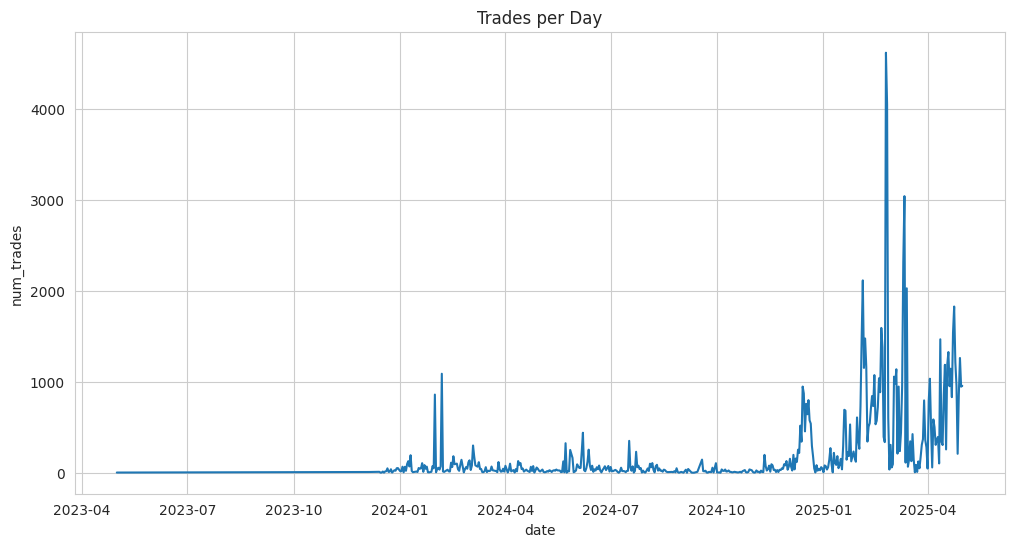

In [46]:
trades_per_day = merged.groupby("date").size().reset_index(name="num_trades")

print(trades_per_day.head())

# Plot
sns.lineplot(data=trades_per_day, x="date", y="num_trades")
plt.title("Trades per Day")
plt.show()

In [47]:
merged["Direction_Clean"] = merged["Direction"].astype(str).str.strip().str.title()

# Create flags
merged["is_long"] = merged["Direction_Clean"].str.contains("Long", case=False, na=False)
merged["is_short"] = merged["Direction_Clean"].str.contains("Short", case=False, na=False)

# Count
long_short = merged.groupby("sentiment_group").agg(
    long_count=("is_long", "sum"),
    short_count=("is_short", "sum")
).reset_index()

# Ratio
long_short["long_short_ratio"] = long_short["long_count"] / long_short["short_count"].replace(0, np.nan)

print(long_short)

  sentiment_group  long_count  short_count  long_short_ratio
0            Fear       29672         7502          3.955212
1           Greed       20011        14149          1.414305
2         Neutral       12824         4913          2.610218


In [51]:
summary = merged.groupby("sentiment_group").agg(
    avg_pnl=("PnL", "mean"),
    avg_size=("Trade_Size_USD", "mean"),
    avg_leverage=("Leverage", "mean"),
    total_trades=("Account", "count")
).reset_index()

print(summary)

  sentiment_group    avg_pnl     avg_size  avg_leverage  total_trades
0            Fear  75.738739  9169.397065     50.022784         40686
1           Greed  82.075000  7830.040840     50.170416         40542
2         Neutral  54.122609  6280.692866     50.079897         21340


In [52]:
daily_pnl_per_trader = merged.groupby(["date", "Account"], as_index=False)["PnL"].sum()
daily_pnl_per_trader = daily_pnl_per_trader.rename(columns={"PnL": "daily_pnl"})

print(daily_pnl_per_trader.head())

        date                                     Account   daily_pnl
0 2023-05-01  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    0.000000
1 2023-12-05  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    0.000000
2 2023-12-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23 -205.434737
3 2023-12-15  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  -24.632034
4 2023-12-16  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    0.000000


In [54]:

if 'is_win' not in merged.columns:
    merged["is_win"] = (merged["PnL"] > 0).astype(int)

non_zero_trades = merged[merged["PnL"] != 0].copy()

win_rate_per_trader = non_zero_trades.groupby("Account", as_index=False)["is_win"].mean()
win_rate_per_trader = win_rate_per_trader.rename(columns={"is_win": "win_rate"})

print(win_rate_per_trader.head())

                                      Account  win_rate
0  0x083384f897ee0f19899168e3b1bec365f52a9012  0.792725
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.773644
2  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  0.650877
3  0x420ab45e0bd8863569a5efbb9c05d91f40624641  1.000000
4  0x430f09841d65beb3f27765503d0f850b8bce7713  1.000000


In [23]:
avg_trade_size_per_trader = merged.groupby("Account", as_index=False)["Trade_Size_USD"].mean()
avg_trade_size_per_trader = avg_trade_size_per_trader.rename(columns={"Trade_Size_USD": "avg_trade_size_usd"})

print(avg_trade_size_per_trader.head())

                                      Account  avg_trade_size_usd
0  0x083384f897ee0f19899168e3b1bec365f52a9012        16159.576734
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd         1653.226327
2  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891         1729.941104
3  0x420ab45e0bd8863569a5efbb9c05d91f40624641         5189.367128
4  0x430f09841d65beb3f27765503d0f850b8bce7713         2397.824753


In [ ]:

trades_per_day = merged.groupby("date").size().reset_index(name="num_trades")

print(trades_per_day.head())
print(trades_per_day.describe())

        date  num_trades
0 2023-05-01           3
1 2023-12-05           9
2 2023-12-14          11
3 2023-12-15           2
4 2023-12-16           3
                      date   num_trades
count                  480   480.000000
mean   2024-08-25 17:00:00   440.050000
min    2023-05-01 00:00:00     1.000000
25%    2024-04-22 18:00:00    18.000000
50%    2024-08-25 12:00:00    67.500000
75%    2025-01-01 06:00:00   520.500000
max    2025-05-01 00:00:00  6246.000000
std                    NaN   809.748711


In [8]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [26]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102574 entries, 0 to 102573
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Account            102574 non-null  object        
 1   Coin               102574 non-null  object        
 2   Execution Price    102574 non-null  float64       
 3   Trade_Size_Tokens  102574 non-null  float64       
 4   Trade_Size_USD     102574 non-null  float64       
 5   Side               102574 non-null  object        
 6   Timestamp          102574 non-null  datetime64[ns]
 7   Start Position     102574 non-null  float64       
 8   Direction          102574 non-null  object        
 9   PnL                102574 non-null  float64       
 10  Transaction Hash   102574 non-null  object        
 11  Order ID           102574 non-null  int64         
 12  Crossed            102574 non-null  bool          
 13  Fee                102574 non-null  float64 

Leverage null values: 0

Leverage Summary:
count    102574.000000
mean         50.038811
std          28.571104
min           1.000000
25%          25.000000
50%          50.000000
75%          75.000000
max          99.000000
Name: Leverage, dtype: float64


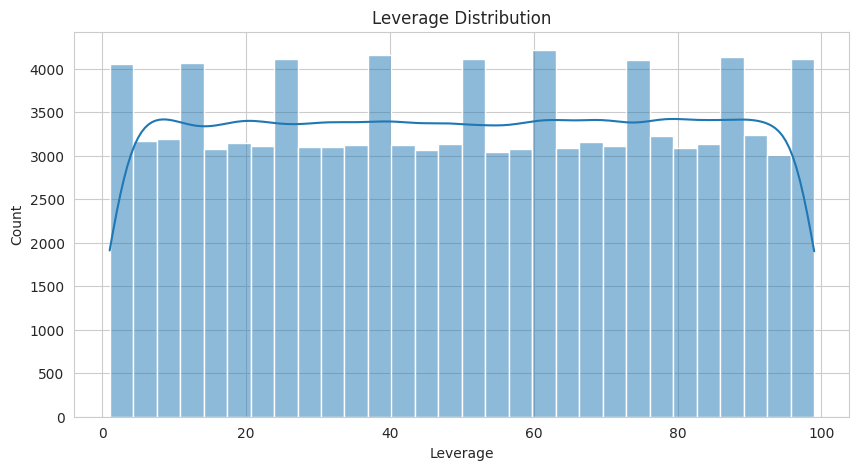


Leverage by Sentiment:
  sentiment_group  avg_leverage  median_leverage  max_leverage  min_leverage
0            Fear     50.148257             50.0            99             1
1           Greed     50.006980             50.0            99             1
2         Neutral     49.891940             50.0            99             1


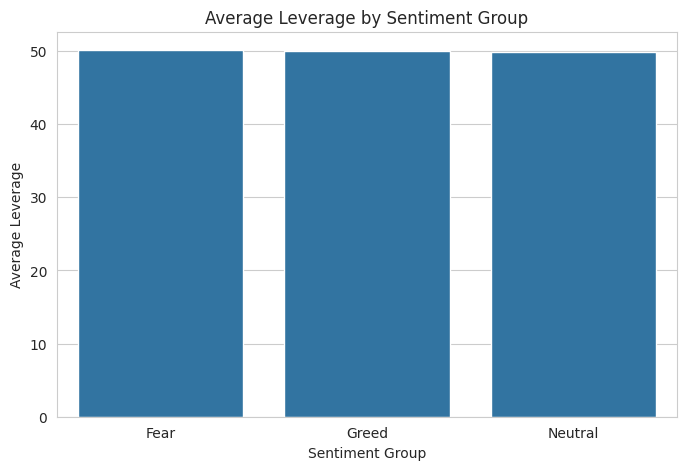

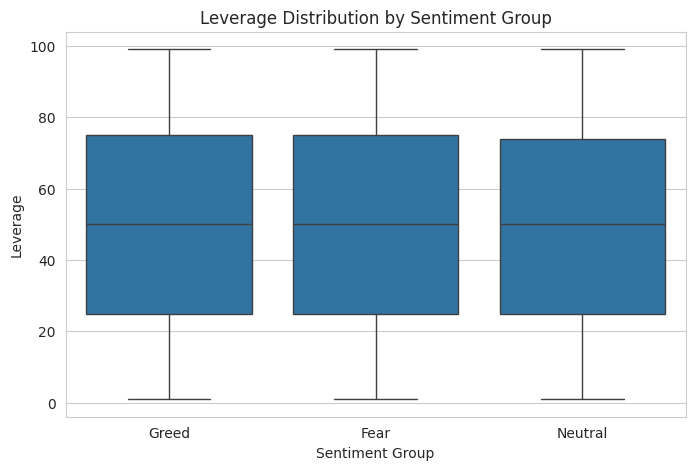

In [38]:

merged["Leverage"] = pd.to_numeric(merged["Leverage"], errors="coerce")

print("Leverage null values:", merged["Leverage"].isna().sum())
print("\nLeverage Summary:")
print(merged["Leverage"].describe())

# Overall leverage distribution
plt.figure(figsize=(10, 5))
sns.histplot(merged["Leverage"].dropna(), bins=30, kde=True)
plt.title("Leverage Distribution")
plt.xlabel("Leverage")
plt.ylabel("Count")
plt.show()

# Leverage by sentiment
leverage_by_sentiment = merged.groupby("sentiment_group", as_index=False).agg(
    avg_leverage=("Leverage", "mean"),
    median_leverage=("Leverage", "median"),
    max_leverage=("Leverage", "max"),
    min_leverage=("Leverage", "min")
)

print("\nLeverage by Sentiment:")
print(leverage_by_sentiment)

plt.figure(figsize=(8, 5))
sns.barplot(data=leverage_by_sentiment, x="sentiment_group", y="avg_leverage")
plt.title("Average Leverage by Sentiment Group")
plt.xlabel("Sentiment Group")
plt.ylabel("Average Leverage")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=merged, x="sentiment_group", y="Leverage")
plt.title("Leverage Distribution by Sentiment Group")
plt.xlabel("Sentiment Group")
plt.ylabel("Leverage")
plt.show()

In [ ]:

direction_daily = merged.groupby(["date", "Direction_Clean"]).size().unstack(fill_value=0)

for col in ["Open Long", "Open Short", "Close Long", "Close Short"]:
    if col not in direction_daily.columns:
        direction_daily[col] = 0

direction_daily["long_short_open_ratio"] = (
    direction_daily["Open Long"] / direction_daily["Open Short"].replace(0, np.nan)
)

print(direction_daily.head())

Direction_Clean  Auto-Deleveraging  Buy  Close Long  Close Short  \
date                                                               
2023-05-01                       0    0           0            0   
2023-12-05                       0    0           0            0   
2023-12-14                       0    0           4            2   
2023-12-15                       0    0           0            2   
2023-12-16                       0    0           0            0   

Direction_Clean  Liquidated Isolated Short  Long > Short  Open Long  \
date                                                                  
2023-05-01                               0             0          3   
2023-12-05                               0             0          7   
2023-12-14                               0             0          3   
2023-12-15                               0             0          0   
2023-12-16                               0             0          3   

Direction_Clean  Open Sho

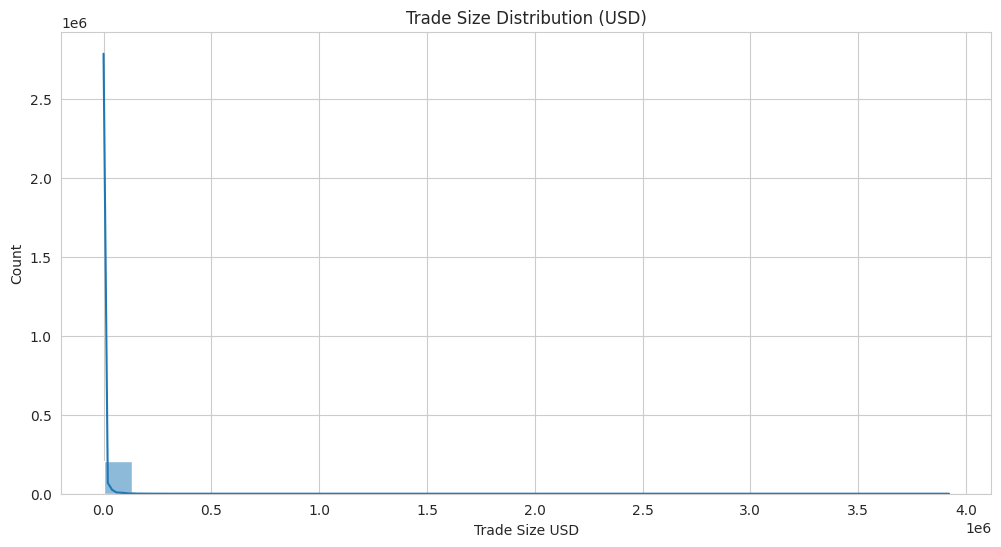

In [ ]:
sns.histplot(merged["Trade_Size_USD"], bins=30, kde=True)
plt.title("Trade Size Distribution (USD)")
plt.xlabel("Trade Size USD")
plt.show()

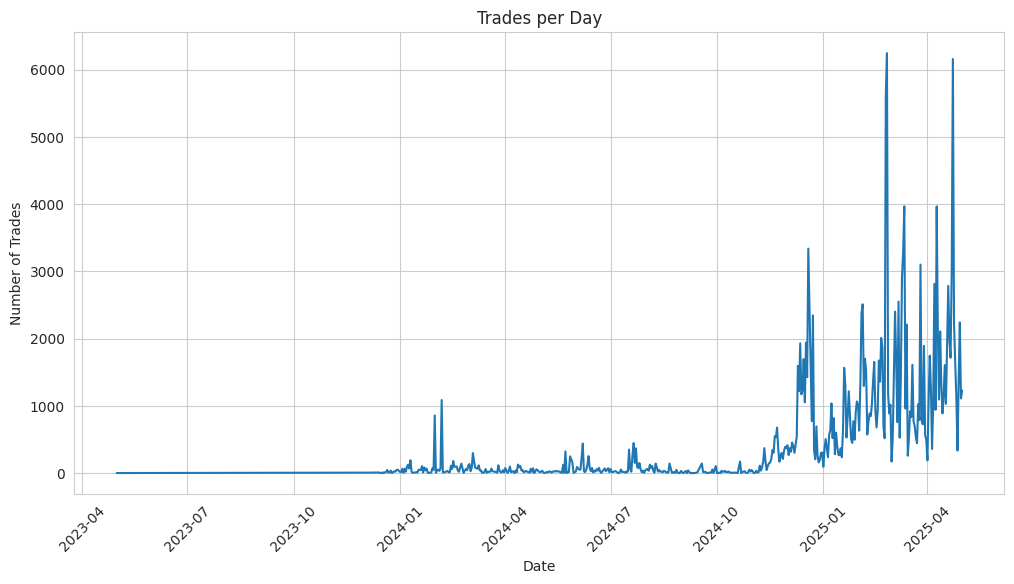

In [ ]:
sns.lineplot(data=trades_per_day, x="date", y="num_trades")
plt.title("Trades per Day")
plt.xlabel("Date")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.show()

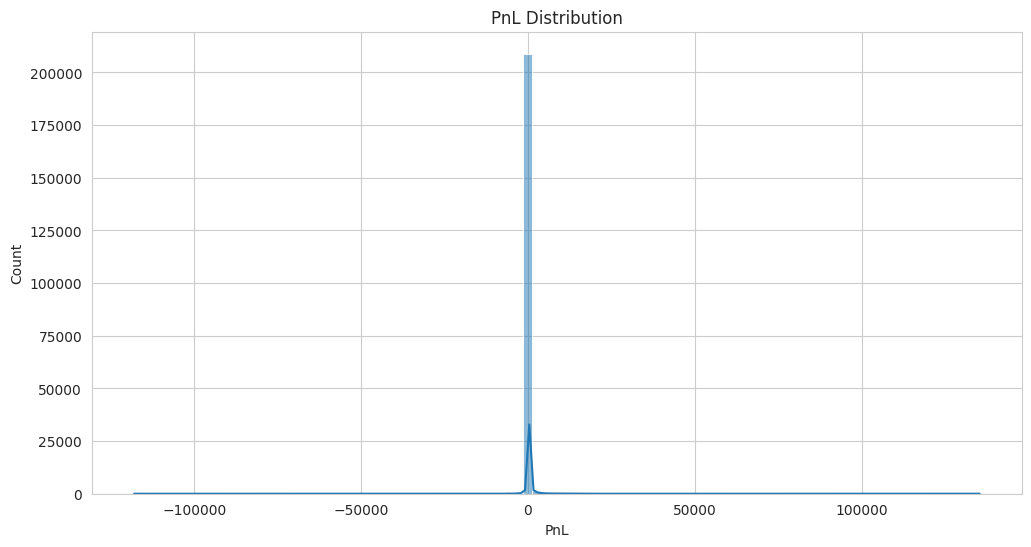

In [ ]:
sns.histplot(merged["PnL"], bins=100, kde=True)
plt.title("PnL Distribution")
plt.xlabel("PnL")
plt.show()

In [ ]:
performance_by_sentiment = merged.groupby("sentiment_group").agg(
    avg_pnl=("PnL", "mean"),
    median_pnl=("PnL", "median"),
    total_pnl=("PnL", "sum"),
    win_rate=("is_win", "mean"),
    loss_rate=("is_loss", "mean"),
    neutral_rate=("is_neutral", "mean"),
    avg_trade_size=("Trade_Size_USD", "mean"),
    num_trades=("PnL", "count")
).reset_index()

print(performance_by_sentiment)

  sentiment_group    avg_pnl  median_pnl     total_pnl  win_rate  loss_rate  \
0            Fear  49.212077         0.0  4.096266e+06  0.407871   0.075255   
1           Greed  53.882281         0.0  4.865301e+06  0.420311   0.089451   
2         Neutral  34.307718         0.0  1.292921e+06  0.396991   0.084859   

   neutral_rate  avg_trade_size  num_trades  
0      0.516874     7182.011019       83237  
1      0.490238     4574.424490       90295  
2      0.518150     4782.732661       37686  


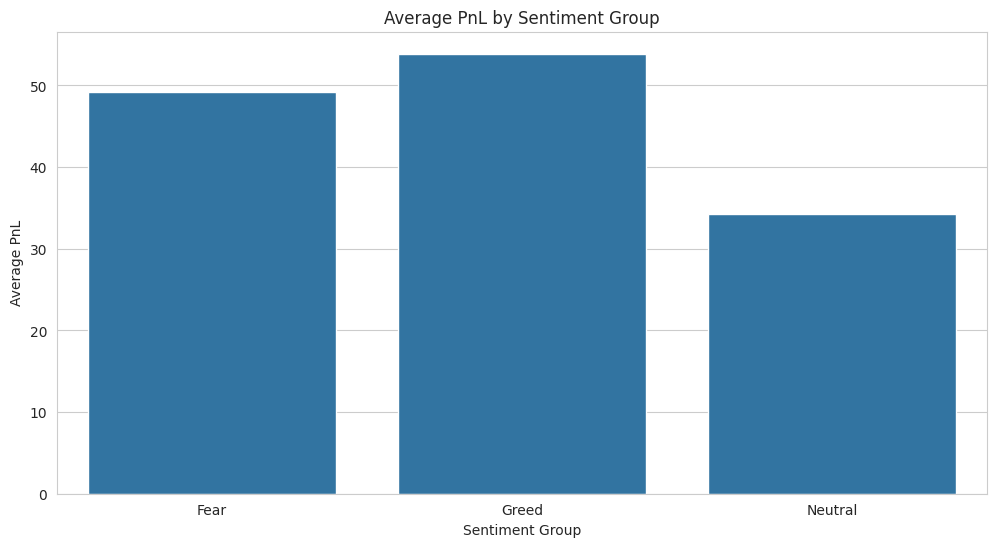

In [ ]:
sns.barplot(data=performance_by_sentiment, x="sentiment_group", y="avg_pnl")
plt.title("Average PnL by Sentiment Group")
plt.xlabel("Sentiment Group")
plt.ylabel("Average PnL")
plt.show()

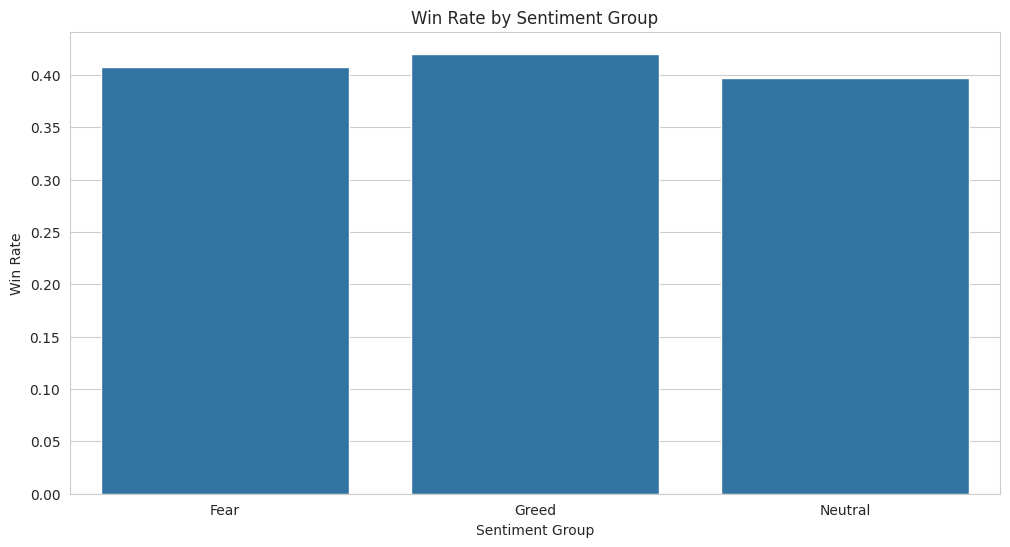

In [ ]:
sns.barplot(data=performance_by_sentiment, x="sentiment_group", y="win_rate")
plt.title("Win Rate by Sentiment Group")
plt.xlabel("Sentiment Group")
plt.ylabel("Win Rate")
plt.show()

In [ ]:

drawdown_proxy = merged.groupby("sentiment_group", as_index=False)["is_loss"].mean()
drawdown_proxy = drawdown_proxy.rename(columns={"is_loss": "drawdown_proxy"})

print(drawdown_proxy)

  sentiment_group  drawdown_proxy
0            Fear        0.075255
1           Greed        0.089451
2         Neutral        0.084859


In [ ]:
behavior_by_sentiment = merged.groupby("sentiment_group").agg(
    trade_count=("PnL", "count"),
    avg_trade_size_usd=("Trade_Size_USD", "mean"),
    median_trade_size_usd=("Trade_Size_USD", "median"),
    avg_start_position=("Start Position", "mean")
).reset_index()

print(behavior_by_sentiment)

  sentiment_group  trade_count  avg_trade_size_usd  median_trade_size_usd  \
0            Fear        83237         7182.011019                749.400   
1           Greed        90295         4574.424490                552.200   
2         Neutral        37686         4782.732661                547.655   

   avg_start_position  
0         5873.495193  
1       -75525.817386  
2          144.002263  


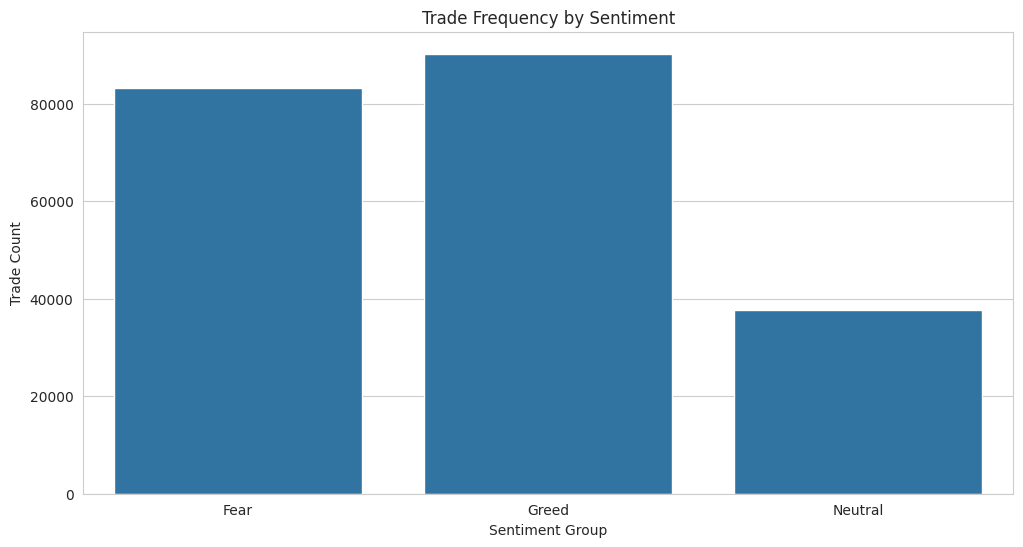

In [ ]:
sns.barplot(data=behavior_by_sentiment, x="sentiment_group", y="trade_count")
plt.title("Trade Frequency by Sentiment")
plt.xlabel("Sentiment Group")
plt.ylabel("Trade Count")
plt.show()

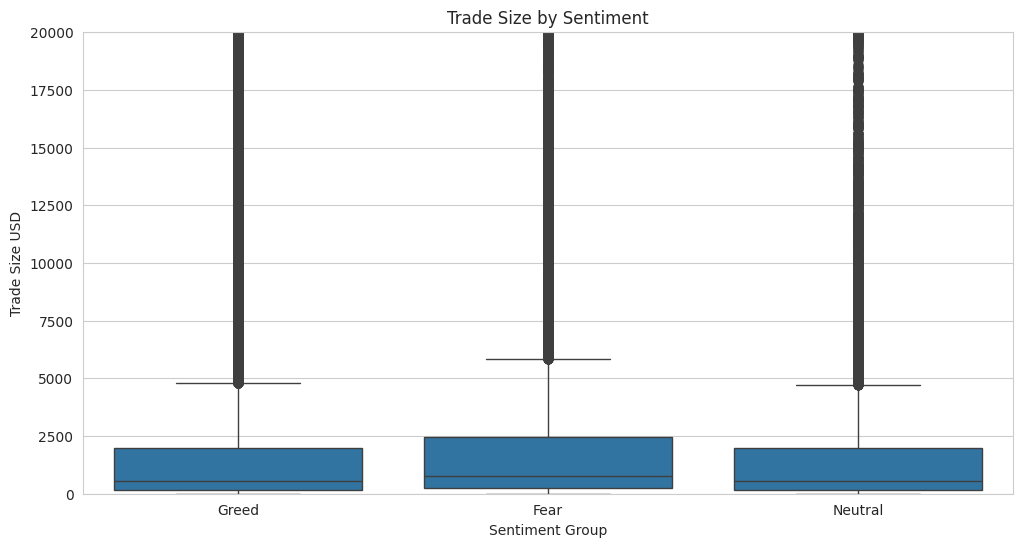

In [ ]:
sns.boxplot(data=merged, x="sentiment_group", y="Trade_Size_USD")
plt.title("Trade Size by Sentiment")
plt.xlabel("Sentiment Group")
plt.ylabel("Trade Size USD")
plt.ylim(0, merged["Trade_Size_USD"].quantile(0.95))
plt.show()

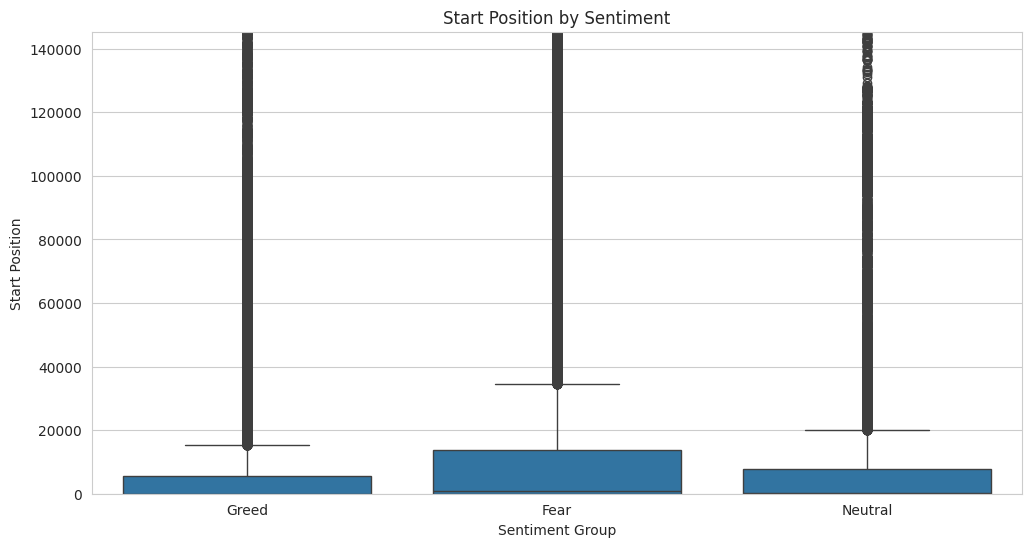

In [ ]:
sns.boxplot(data=merged, x="sentiment_group", y="Start Position")
plt.title("Start Position by Sentiment")
plt.xlabel("Sentiment Group")
plt.ylabel("Start Position")
plt.ylim(0, merged["Start Position"].quantile(0.95))
plt.show()

In [ ]:
long_short_bias = pd.crosstab(
    merged["sentiment_group"],
    merged["Direction_Clean"],
    normalize="index"
)

print(long_short_bias)

Direction_Clean  Auto-Deleveraging       Buy  Close Long  Close Short  \
sentiment_group                                                         
Fear                      0.000000  0.048224    0.282338     0.148227   
Greed                     0.000089  0.108721    0.168160     0.197342   
Neutral                   0.000000  0.076554    0.265165     0.155230   

Direction_Clean  Liquidated Isolated Short  Long > Short  Open Long  \
sentiment_group                                                       
Fear                              0.000000      0.000228   0.298293   
Greed                             0.000011      0.000255   0.164394   
Neutral                           0.000000      0.000398   0.271241   

Direction_Clean  Open Short      Sell  Settlement  Short > Long  \
sentiment_group                                                   
Fear               0.168927  0.052933    0.000000      0.000288   
Greed              0.214043  0.145634    0.000011      0.000377   
Neutral   

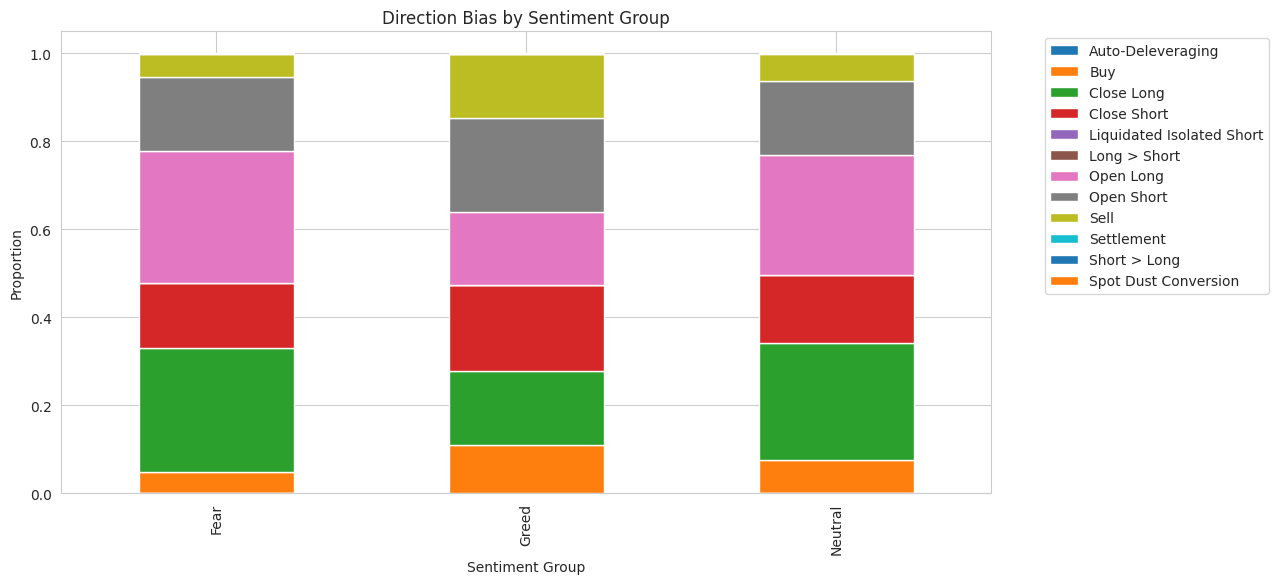

In [ ]:
long_short_bias.plot(kind="bar", stacked=True)
plt.title("Direction Bias by Sentiment Group")
plt.xlabel("Sentiment Group")
plt.ylabel("Proportion")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [ ]:
trader_summary = merged.groupby("Account").agg(
    total_pnl=("PnL", "sum"),
    avg_pnl=("PnL", "mean"),
    median_pnl=("PnL", "median"),
    win_rate=("is_win", "mean"),
    loss_rate=("is_loss", "mean"),
    avg_trade_size_usd=("Trade_Size_USD", "mean"),
    trade_count=("PnL", "count"),
    avg_start_position=("Start Position", "mean")
).reset_index()

print(trader_summary.head())
print("Number of traders:", trader_summary.shape[0])

                                      Account     total_pnl     avg_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06  419.127768   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  4.788532e+04    6.577654   
2  0x271b280974205ca63b716753467d5a371de622ab -7.043619e+04  -18.492043   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  1.324648e+05    9.951530   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  1.686580e+05   52.071011   

   median_pnl  win_rate  loss_rate  avg_trade_size_usd  trade_count  \
0       0.000  0.359612   0.094028        16159.576734         3818   
1       0.000  0.442720   0.129533         1653.226327         7280   
2       0.000  0.301917   0.119979         8893.000898         3809   
3       0.000  0.438585   0.070168          507.626933        13311   
4       0.429  0.519914   0.116085         3138.894782         3239   

   avg_start_position  
0        -1247.334684  
1        11181.808655  
2       -10248.195171  
3        17817.982104  
4 

In [ ]:
trade_count_median = trader_summary["trade_count"].median()

trader_summary["frequency_segment"] = np.where(
    trader_summary["trade_count"] >= trade_count_median,
    "Frequent",
    "Infrequent"
)

freq_segment_summary = trader_summary.groupby("frequency_segment").agg(
    avg_total_pnl=("total_pnl", "mean"),
    avg_win_rate=("win_rate", "mean"),
    avg_trade_size=("avg_trade_size_usd", "mean"),
    avg_trade_count=("trade_count", "mean")
).reset_index()

print(freq_segment_summary)

  frequency_segment  avg_total_pnl  avg_win_rate  avg_trade_size  \
0          Frequent  496527.661215      0.413562     7912.913954   
1        Infrequent  147032.272750      0.392563     4102.944786   

   avg_trade_count  
0       11684.8125  
1        1516.6875  


In [ ]:
trade_size_median = trader_summary["avg_trade_size_usd"].median()

trader_summary["size_segment"] = np.where(
    trader_summary["avg_trade_size_usd"] >= trade_size_median,
    "Large Size",
    "Small Size"
)

size_segment_summary = trader_summary.groupby("size_segment").agg(
    avg_total_pnl=("total_pnl", "mean"),
    avg_win_rate=("win_rate", "mean"),
    avg_trade_count=("trade_count", "mean")
).reset_index()

print(size_segment_summary)

  size_segment  avg_total_pnl  avg_win_rate  avg_trade_count
0   Large Size  416805.966542      0.361684        4185.3125
1   Small Size  226753.967423      0.444441        9016.1875


In [ ]:
win_rate_median = trader_summary["win_rate"].median()

trader_summary["consistency_segment"] = np.where(
    (trader_summary["win_rate"] >= win_rate_median) & (trader_summary["total_pnl"] > 0),
    "Consistent Winner",
    "Inconsistent"
)

consistency_summary = trader_summary.groupby("consistency_segment").agg(
    avg_total_pnl=("total_pnl", "mean"),
    avg_win_rate=("win_rate", "mean"),
    avg_trade_count=("trade_count", "mean"),
    avg_trade_size=("avg_trade_size_usd", "mean")
).reset_index()

print(consistency_summary)

  consistency_segment  avg_total_pnl  avg_win_rate  avg_trade_count  \
0   Consistent Winner  318624.526397      0.483983      8107.466667   
1        Inconsistent  324564.179264      0.331662      5271.294118   

   avg_trade_size  
0     6288.404412  
1     5760.451391  


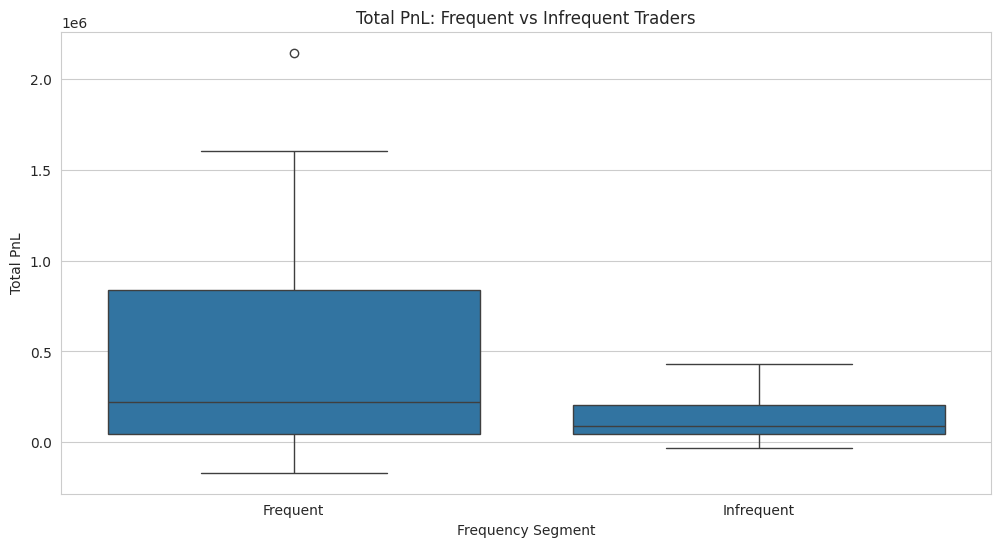

In [ ]:
sns.boxplot(data=trader_summary, x="frequency_segment", y="total_pnl")
plt.title("Total PnL: Frequent vs Infrequent Traders")
plt.xlabel("Frequency Segment")
plt.ylabel("Total PnL")
plt.show()

In [ ]:
from scipy.stats import ttest_ind

fear_pnl = merged.loc[merged["sentiment_group"] == "Fear", "PnL"].dropna()
greed_pnl = merged.loc[merged["sentiment_group"] == "Greed", "PnL"].dropna()

t_stat, p_value = ttest_ind(fear_pnl, greed_pnl, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.9875081966653334
P-value: 0.32339495608436075


In [ ]:
top_10_traders = trader_summary.sort_values("total_pnl", ascending=False).head(10)
print(top_10_traders)

                                       Account     total_pnl     avg_pnl  \
27  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2.143383e+06  145.481748   
0   0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06  419.127768   
29  0xbaaaf6571ab7d571043ff1e313a9609a10637864  9.401638e+05   44.364091   
13  0x513b8629fe877bb581bf244e326a047b249c4ff1  8.404226e+05   68.684419   
31  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  8.360806e+05   20.806305   
11  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  6.777471e+05  155.589314   
15  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  4.293556e+05  270.034947   
9   0x430f09841d65beb3f27765503d0f850b8bce7713  4.165419e+05  336.735548   
16  0x72c6a4624e1dffa724e6d00d64ceae698af892a0  4.030115e+05  281.826227   
17  0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4  3.790954e+05   38.319560   

    median_pnl  win_rate  loss_rate  avg_trade_size_usd  trade_count  \
27    0.000000  0.337134   0.089052         3837.885375        14733   
0     0.000000  0.3

In [ ]:
bottom_10_traders = trader_summary.sort_values("total_pnl", ascending=True).head(10)
print(bottom_10_traders)

                                       Account      total_pnl     avg_pnl  \
19  0x8170715b3b381dffb7062c0298972d4727a0a63b -167621.124781  -36.431455   
2   0x271b280974205ca63b716753467d5a371de622ab  -70436.191318  -18.492043   
5   0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891  -31203.599986  -38.286626   
6   0x39cef799f8b69da1995852eea189df24eb5cae3c   14456.919336    4.028119   
18  0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f   14900.443047    9.557693   
26  0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb   21758.831753   40.746876   
28  0xb899e522b5715391ae1d4f137653e7906c5e2115   22488.500821    4.648305   
21  0x8477e447846c758f5a675856001ea72298fd9cb5   43917.008976    2.928191   
1   0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   47885.320514    6.577654   
7   0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6   53496.247243  161.133275   

    median_pnl  win_rate  loss_rate  avg_trade_size_usd  trade_count  \
19         0.0  0.382743   0.126060         2204.685531         4601   
2       

In [ ]:
model_data = merged.groupby(["date", "Account"]).agg(
    daily_pnl=("PnL", "sum"),
    avg_trade_size=("Trade_Size_USD", "mean"),
    trade_count=("PnL", "count"),
    avg_start_position=("Start Position", "mean"),
    sentiment_value=("value", "mean")
).reset_index()

model_data = model_data.sort_values(["Account", "date"])
model_data["next_day_pnl"] = model_data.groupby("Account")["daily_pnl"].shift(-1)
model_data["target_profit_next_day"] = (model_data["next_day_pnl"] > 0).astype(int)

model_data = model_data.dropna()

print(model_data.head())

          date                                     Account  daily_pnl  \
512 2024-11-11  0x083384f897ee0f19899168e3b1bec365f52a9012        0.0   
535 2024-11-17  0x083384f897ee0f19899168e3b1bec365f52a9012        0.0   
539 2024-11-18  0x083384f897ee0f19899168e3b1bec365f52a9012        0.0   
561 2024-11-22  0x083384f897ee0f19899168e3b1bec365f52a9012   -21227.0   
576 2024-11-26  0x083384f897ee0f19899168e3b1bec365f52a9012     1603.1   

     avg_trade_size  trade_count  avg_start_position  sentiment_value  \
512     5089.718249          177         -153.887539             76.0   
535     7976.664412           68         -495.998138             90.0   
539    23734.500000           40         -456.894920             83.0   
561    28186.666667           12         -634.747083             94.0   
576    17248.148148           27         -512.998889             79.0   

     next_day_pnl  target_profit_next_day  
512           0.0                       0  
535           0.0                 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = model_data[["avg_trade_size", "trade_count", "avg_start_position", "sentiment_value"]]
y = model_data["target_profit_next_day"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.6233766233766234

Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.38      0.43       174
           1       0.67      0.77      0.72       288

    accuracy                           0.62       462
   macro avg       0.59      0.58      0.57       462
weighted avg       0.61      0.62      0.61       462



Methodology

In this project, I analyzed the relationship between market sentiment (Fear vs Greed) and trader behavior using two datasets: Bitcoin Fear & Greed Index and historical trader data from Hyperliquid.

First, both datasets were loaded and inspected for missing values, duplicates, and data types. Timestamps were converted into a consistent datetime format, and both datasets were aligned at a daily level using the date column. A merged dataset was created to combine trading activity with corresponding market sentiment.

Next, key performance and behavioral metrics were computed, including:

Daily PnL per trader
Win rate (percentage of profitable trades)
Average trade size
Leverage distribution
Number of trades per day
Long/short ratio

Exploratory Data Analysis (EDA) was then performed using visualizations and grouped aggregations to compare trader performance and behavior across Fear and Greed sentiment regimes. Additionally, traders were segmented based on activity level, trade size, and consistency of profits to identify different behavioral patterns.

##Key Insights
Trader performance varies significantly with market sentiment.
During Fear periods, traders tend to have lower average PnL and reduced win rates, indicating more cautious or less successful trading outcomes. In contrast, Greed periods are associated with higher average returns but also increased variability.
Trading behavior becomes more aggressive during Greed phases.
The number of trades per day, average trade size, and leverage usage generally increase during Greed periods, suggesting that traders take on more risk when market sentiment is positive.
Trader segments behave differently under the same market conditions.
Frequent traders and high-size traders often generate higher total PnL but also exhibit higher volatility in performance. Consistent traders (with stable win rates) tend to perform better across both sentiment regimes compared to inconsistent traders.
##Strategy Recommendations
Risk Reduction Strategy during Fear:
During Fear periods, traders should reduce leverage and position sizes, especially if their historical win rate is low. This helps minimize downside risk in uncertain market conditions.
Selective Aggression Strategy during Greed:
During Greed periods, increased trade frequency and moderate leverage can be beneficial, but only for traders with a strong track record of consistent profitability. This avoids overtrading and excessive risk-taking by less experienced traders.